<a href="https://colab.research.google.com/github/teguhsmlnna666/Teguh-Esa-Maulanna_2411532005_ML2526/blob/main/Praktikum8/PrincipalComponentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape data:", X.shape)

Shape data: (569, 30)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
cov_matrix = np.cov(X_scaled.T)
print("Shape Covariance Matrix:", cov_matrix.shape)

Shape Covariance Matrix: (30, 30)


In [5]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues[:5])
print("Eigencevtors shape:", eigenvectors.shape)

Eigenvalues:
 [13.30499079  5.7013746   2.82291016  1.98412752  1.65163324]
Eigencevtors shape: (30, 30)


In [6]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

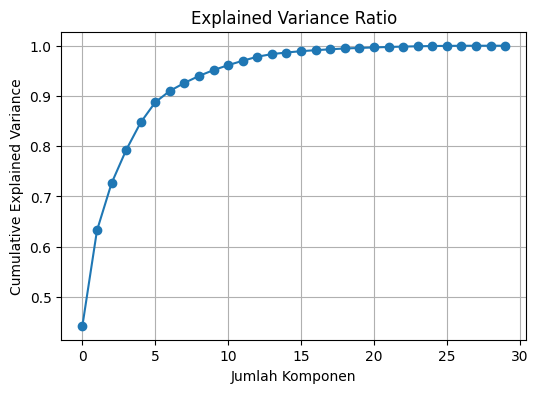

In [7]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio")
plt.grid()
plt.show()

In [8]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

print("Shape setelah PCA:", X_pca.shape)

Shape setelah PCA: (569, 2)


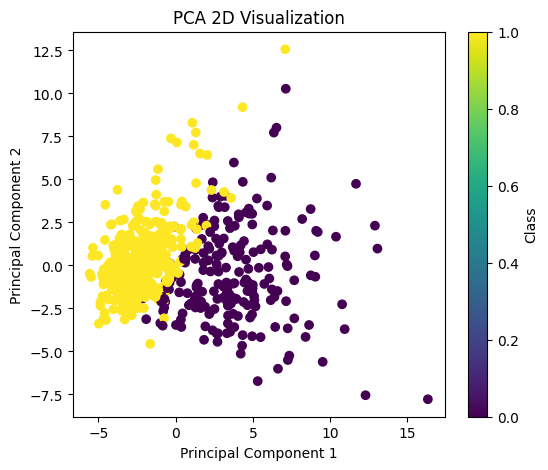

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")
plt.colorbar(label="Class")
plt.show()

In [10]:
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)

print("Jumlah komponen untuk 90% variance:", pca_90.n_components_)

Jumlah komponen untuk 90% variance: 7
